# Data Q&A Agent - Azure AI Foundry (New Experience)

This notebook creates an Azure AI Foundry agent with Code Interpreter so you can upload CSV/Excel files and ask natural-language questions about your data.

This notebook is for the Foundry new experience only (versioned agents + Responses API with Conversations), not Foundry classic threads/runs.

## Local Prerequisites

- Python 3.14.3
- Option 1 (Conda): `conda create -n sample_foundry_v2 python=3.14.3 ipykernel -y`
- Option 2 (venv): install Python 3.14, then run `py -3.14 -m venv .venv`
- `.env` file populated (copy from `.env.template`)
- `pip install -r requirements.txt`

For full from-scratch setup (including installing Python/Conda), see `README.md`.

---

## Azure Setup (run once from CLI / PowerShell)

The Foundry new experience requires a storage account connected to your project.
The Foundry project managed identity must have `Storage Blob Data Contributor` on that storage account so Code Interpreter can read/write files.

Important: Foundry resource and Foundry project have separate managed identities.
Assign storage role to the project managed identity (not only the resource identity).

```bash
# 1. Create a dedicated storage account (or use existing)
az storage account create \
  --name <STORAGE_ACCOUNT_NAME> \
  --resource-group <YOUR_RESOURCE_GROUP> \
  --location <REGION> \
  --sku Standard_LRS \
  --kind StorageV2 \
  --min-tls-version TLS1_2

# 2. Get the Foundry PROJECT managed identity principal ID
az rest --method GET \
  --url "https://management.azure.com/subscriptions/<SUB_ID>/resourceGroups/<YOUR_RESOURCE_GROUP>/providers/Microsoft.CognitiveServices/accounts/<FOUNDRY_RESOURCE_NAME>/projects/<PROJECT_NAME>?api-version=2025-04-01-preview" \
  --query "identity.principalId" -o tsv

# 3. Assign Storage Blob Data Contributor to the PROJECT identity
az role assignment create \
  --assignee-object-id <PROJECT_PRINCIPAL_ID_FROM_STEP_2> \
  --assignee-principal-type ServicePrincipal \
  --role "Storage Blob Data Contributor" \
  --scope "/subscriptions/<SUB_ID>/resourceGroups/<YOUR_RESOURCE_GROUP>/providers/Microsoft.Storage/storageAccounts/<STORAGE_ACCOUNT_NAME>"

# 4. Connect storage to Foundry project
   Go to https://ai.azure.com -> Management Center -> Connected resources
   Click "+ New connection" -> Data -> Azure Blob Storage
   Select the storage account from step 1
   Set authentication to "Microsoft Entra ID"
```

Note: Wait a few minutes for role assignment propagation before uploading files.

## 1. Install Dependencies
Run this cell once in your active environment (`sample_foundry_v2`)

OR

Follow Steps in README to install requirements in terminal

In [ ]:
# %pip install -r requirements.txt --quiet

Note: you may need to restart the kernel to use updated packages.


## 2. Setup & Configuration

In [1]:
import os
from pathlib import Path
from dotenv import load_dotenv

# Load .env — override=False so runtime env vars take precedence
load_dotenv(override=False)

PROJECT_ENDPOINT = os.getenv("FOUNDRY_PROJECT_ENDPOINT")
MODEL_DEPLOYMENT = os.getenv("FOUNDRY_MODEL_DEPLOYMENT_NAME")

print(f"Project endpoint : {PROJECT_ENDPOINT}")
print(f"Model deployment : {MODEL_DEPLOYMENT}")

Project endpoint : https://sample-proj-resource.services.ai.azure.com/api/projects/sample_project
Model deployment : gpt-4.1


## 3. Create the Foundry Agent with Code Interpreter

The agent uses the **Code Interpreter** tool, which lets it write and execute Python code to analyse your uploaded files.

In the new Foundry experience, agents are **versioned** — each call to `create_version` publishes a new immutable version.

In [2]:
from azure.ai.projects import AIProjectClient
from azure.ai.projects.models import (
    PromptAgentDefinition,
    CodeInterpreterTool,
    AutoCodeInterpreterToolParam,
)
from azure.identity import DefaultAzureCredential

AGENT_NAME = "data-qa-agent-corteva"

# Create the Project client (new Foundry experience)
project_client = AIProjectClient(
    endpoint=PROJECT_ENDPOINT,
    credential=DefaultAzureCredential(),
)

def publish_agent_version(file_ids: list[str] | None = None) -> str:
    """Publish a new immutable agent version in the Foundry new experience.

    Files for Code Interpreter must be bound to the agent tool config.
    The Conversations API handles multi-turn state, not file attachment.
    """
    code_interpreter_tool = (
        CodeInterpreterTool(container=AutoCodeInterpreterToolParam(file_ids=file_ids))
        if file_ids
        else CodeInterpreterTool()
    )

    result = project_client.agents.create_version(
        agent_name=AGENT_NAME,
        definition=PromptAgentDefinition(
            model=MODEL_DEPLOYMENT,
            instructions=(
                "You are a data analyst assistant. The user will upload CSV or Excel files. "
                "Use the Code Interpreter tool to load the data with pandas, explore it, "
                "and answer the user's questions. When useful, create charts or summary tables. "
                "Always show your work by printing intermediate results."
            ),
            tools=[code_interpreter_tool],
        ),
        description="Data Q&A agent with Code Interpreter",
    )
    return result.version

# Publish an initial version (no files). A new version is published when files are attached.
agent_version = publish_agent_version()
print(f"✅ Published agent — Name: {AGENT_NAME}, Version: {agent_version}")

✅ Published agent — Name: data-qa-agent-corteva, Version: 3


## 4. Get the OpenAI Client

In the new Foundry experience, you interact with agents via the **OpenAI Responses API** with **Conversations** for multi-turn state. A conversation stores items (messages, tool calls, tool outputs) and maintains context across calls.

In [3]:
openai_client = project_client.get_openai_client()

# Track the conversation ID for multi-turn conversation
conversation_id = None

print("OpenAI client ready.")

OpenAI client ready.


## 5. Helper — `ask()`

A single function that handles all scenarios:
- **Just a question** — `ask("What's the total revenue?")`
- **Question + attach a file** — `ask("Summarize this", file_path="data.csv")`
- **Question + download generated files** — `ask("Add a profit column and save as Excel", download=True)`
- **All three** — `ask("Clean this and export", file_path="raw.csv", download=True)`

Uses the OpenAI Responses API with `agent_reference` and **Conversations** for multi-turn context. A conversation is created on the first call and reused for follow-ups.

In [4]:
from pathlib import Path

OUTPUT_DIR = Path("output")
OUTPUT_DIR.mkdir(exist_ok=True)

IMAGE_EXTS = {".png", ".jpg", ".jpeg", ".gif", ".svg", ".webp"}

def ask(question: str, file_path: str = None, download: bool = False) -> str:
    """Ask the agent a question via the OpenAI Responses API with Conversations.

    Multi-turn context is maintained via an explicit conversation object
    created with openai.conversations.create().

    Files for Code Interpreter are bound to the agent tool config (the only
    documented approach).  When a file is uploaded, a new agent version is
    published and a fresh conversation is started.

    Args:
        question:  Your natural-language question or instruction.
        file_path: Optional path to a .csv/.xlsx file to upload for this turn.
        download:  If True, download any non-image files the agent generates
                   to output/.  Image files (charts) are ALWAYS downloaded.
    """
    global conversation_id, agent_version

    # --- optionally upload a file and publish a version bound to it ---
    if file_path:
        with open(file_path, "rb") as fp:
            uploaded = openai_client.files.create(
                file=fp,
                purpose="assistants",
            )

        print(f"📎 Uploaded: {file_path} → file ID: {uploaded.id}")

        agent_version = publish_agent_version(file_ids=[uploaded.id])
        conversation_id = None  # start a fresh conversation for new file context
        print(f"🆕 Published agent version with attached file: {agent_version}")

    # --- build the conversation item ---
    input_items = [
        {
            "type": "message",
            "role": "user",
            "content": question,
        }
    ]

    # --- create or reuse a conversation ---
    if not conversation_id:
        conversation = openai_client.conversations.create(items=input_items)
        conversation_id = conversation.id
        print(f"💬 Created conversation: {conversation_id}")
    else:
        openai_client.conversations.items.create(
            conversation_id=conversation_id,
            items=input_items,
        )

    # --- generate a response within the conversation ---
    response = openai_client.responses.create(
        input=question,
        conversation=conversation_id,
        extra_body={
            "agent_reference": {
                "name": AGENT_NAME,
                "version": agent_version,
                "type": "agent_reference",
            }
        },
    )

    # --- collect response text, download images always, other files if requested ---
    response_text = ""
    for item in response.output:
        if item.type == "message":
            for block in item.content:
                if block.type == "output_text":
                    response_text += block.text
                    for ann in getattr(block, "annotations", []) or []:
                        if getattr(ann, "type", None) != "container_file_citation":
                            continue

                        file_id = getattr(ann, "file_id", None)
                        container_id = getattr(ann, "container_id", None)
                        if not file_id or not container_id:
                            continue

                        fname = getattr(ann, "filename", None) or f"output_{file_id}"
                        is_image = Path(fname).suffix.lower() in IMAGE_EXTS

                        if not (download or is_image):
                            continue

                        file_content = openai_client.containers.files.content.retrieve(
                            file_id=file_id,
                            container_id=container_id,
                        )
                        out_path = OUTPUT_DIR / fname
                        out_path.write_bytes(file_content.read())
                        prefix = "🖼️  Downloaded chart" if is_image else "⬇️  Downloaded"
                        print(f"{prefix}: {out_path}")

    return response_text


## 6. Try It — All Combinations in One Conversation

The cells below show every combination of `ask()`:
1. Attach a file + ask a question (creates a new conversation)
2. Follow-up question (no file, no download — continues the same conversation)
3. Ask for a generated file (download=True)
4. Attach a *different* file + ask (starts a new conversation)
5. Plain question with no file context

In [5]:
# 1️⃣ Attach a file + ask a question
print("=" * 60)
print("1. Attach file + question")
print("=" * 60)

answer = ask(
    "What columns are in this file? Give me a quick summary.",
    file_path="sample_data/sample_sales.csv"
)

print(answer)

1. Attach file + question
📎 Uploaded: sample_data/sample_sales.csv → file ID: assistant-PZWsVVnaNH3zpkQ118gbbk
🆕 Published agent version with attached file: 4
💬 Created conversation: conv_a73e991c4a90bfe500coc4nTkbmTcc72PnULBBpEQzXkmreaVe
Here are the columns in your file:

1. **date**
2. **region**
3. **product**
4. **units_sold**
5. **unit_price**
6. **revenue**
7. **cost**

### Quick Summary:
- There are 20 rows in the file.
- **'region'**: 4 unique values.
- **'product'**: 3 unique products.
- **'units_sold'**: Ranges from 45 to 155 (Mean ≈ 97).
- **'unit_price'**: Ranges from 25 to 55 (Mean ≈ 38).
- **'revenue'**: Ranges from 2200 to 5000 (Mean ≈ 3361).
- **'cost'**: Ranges from 1320 to 3125 (Mean ≈ 2132).

If you need details on a specific column or a deeper look into the data, just let me know!


In [11]:
# 2️⃣ Follow-up — no file, no download (agent remembers the CSV)
print("=" * 60)
print("2. Follow-up question (no file)")
print("=" * 60)
answer = ask("Which region has the highest total revenue?")
print(answer)

2. Follow-up question (no file)
The region with the highest total revenue is North, with a total revenue of 20,400. 

Here are the total revenues by region:
- North: 20,400
- South: 16,625
- East: 16,400
- West: 13,800

If you'd like to see this in a chart, just ask!


In [6]:
# 2️⃣ Follow-up — no file, no download (agent remembers the CSV)
print("=" * 60)
print("2. Follow-up question (no file)")
print("=" * 60)
answer = ask("make a bar graph showing revenue by region")
print(answer)

2. Follow-up question (no file)
🖼️  Downloaded chart: output\revenue_by_region.png
The bar graph showing total revenue by region has been created.

You can download and view it here: [Download revenue_by_region.png](sandbox:/mnt/data/revenue_by_region.png)


revenue_by_region.png


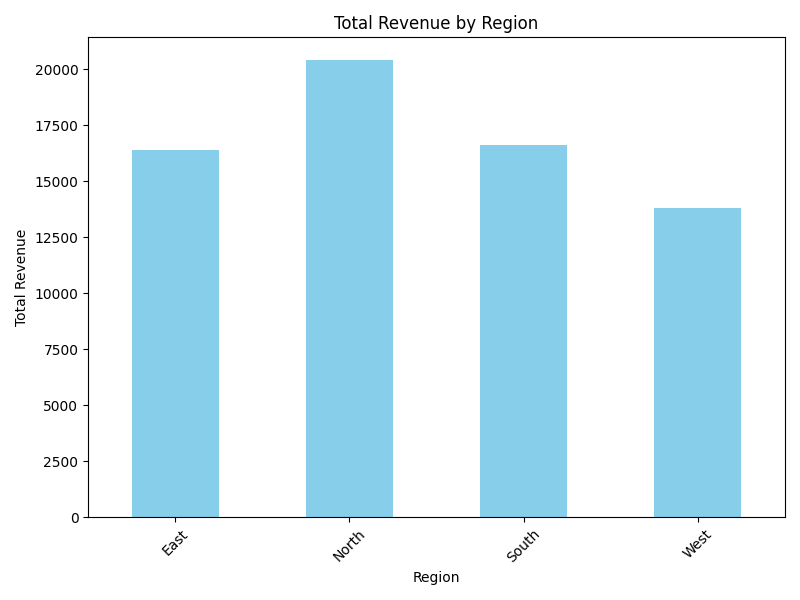

In [7]:
from pathlib import Path
from IPython.display import Image, display

IMAGE_EXTS = {".png", ".jpg", ".jpeg", ".gif", ".webp"}
imgs = [p for p in Path("output").iterdir() if p.suffix.lower() in IMAGE_EXTS]
imgs.sort(key=lambda p: p.stat().st_mtime)
for p in imgs[-3:]:   # last 3 generated
    print(p.name)
    display(Image(filename=str(p)))

In [8]:
import shutil
from pathlib import Path
import os

shutil.rmtree(Path("output"), ignore_errors=True)
print("output/ deleted")


output/ deleted


In [7]:
# 3️⃣ Ask to generate a modified file → downloads to output/
print("=" * 60)
print("3. Generate + download a modified file")
print("=" * 60)
answer = ask(
    "Add a 'profit' column (revenue minus cost) and a 'profit_margin_pct' column. "
    "Save the result as a new Excel file.",
    download=True
)
print(answer)

3. Generate + download a modified file
⬇️  Downloaded: output\sample_sales_with_profit.xlsx
I've added the 'profit' and 'profit_margin_pct' columns to your data.

You can download the updated Excel file here:
[Download the Excel file](sandbox:/mnt/data/sample_sales_with_profit.xlsx)

Let me know if you need any further analysis or adjustments!


In [8]:
# 3️⃣ Ask to generate a modified file → downloads to output/
print("=" * 60)
print("3. Generate + download a modified file")
print("=" * 60)
answer = ask(
    "add another column that indicates whether profit_margin_pct is >= 35 (1) or < (0)."
    "Save the result as a new Excel file.",
    download=True
)
print(answer)

3. Generate + download a modified file
⬇️  Downloaded: output\sample_sales_with_profit_margin_flag.xlsx
The new column, 'high_profit_margin', indicates whether 'profit_margin_pct' is at least 35 (1 if true, 0 if false).

You can download the updated Excel file here:
[Download the Excel file](sandbox:/mnt/data/sample_sales_with_profit_margin_flag.xlsx)

Let me know if you need anything else!


## 7. Cleanup

Delete the agent when you're done. (Conversations are server-managed and don't require manual cleanup.)

In [ ]:
project_client.agents.delete(agent_name=AGENT_NAME)
print(f"Agent '{AGENT_NAME}' deleted.")